# LIDC-IDRI Dataset Analysis & Preprocessing
**Dissertation:** Development and Evaluation of an Explainable Deep Transfer Learning Framework for Lung CT Image Classification Using Public Medical Imaging Data
**Student:** Ranjeet Kumar Mahato (u3035175)
**Stage:** Dataset Analysis + Preprocessing (Objectives 2 & 3, Phase 2-4 of methodology)

This notebook implements:
1. Environment setup (Drive mount, packages)
2. Dataset inventory / structure inspection
3. Parsing LIDC-IDRI XML radiologist annotations (malignancy ratings, nodule ROI)
4. Building a master nodule-level dataframe and defining classification labels
5. Dataset analysis: class distribution, duplicate detection, DICOM quality/consistency checks
6. Nodule slice extraction with lung windowing
7. Resizing, normalisation
8. Patient-level stratified 70/15/15 train/val/test split (prevents data leakage)
9. Augmentation pipeline definition (train split only)
10. Automated dataset summary report (feeds directly into your dissertation's Dataset Analysis section)

> **Before running:** edit the `DATA_ROOT` and `OUTPUT_ROOT` paths in the Configuration cell to match your Google Drive folder structure.


## 1. Setup: Mount Drive & Install Packages

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

dataset_path = Path("/content/drive/MyDrive/Dissertation/Dataset/Raw")
annotation_xml_path = Path("/content/drive/MyDrive/Dissertation/Dataset/ANNOTATION_STAGING")

os.makedirs(dataset_path, exist_ok=True)
os.makedirs(annotation_xml_path, exist_ok=True)

print(dataset_path.exists())
print(annotation_xml_path.exists())

True
True


## 2. Install packages

In [ ]:
!pip -q install pydicom pylidc scikit-learn opencv-python-headless matplotlib seaborn pandas numpy tqdm imagehash pylidc
print("Packages ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 17.6 MB/s eta 0:00:00
Packages ready.


##3. Verify Dataset

In [ ]:
patients = sorted([p for p in dataset_path.iterdir() if p.is_dir()])

print("Total Patients:", len(patients))
print(patients[:3])

Total Patients: 10
[PosixPath('/content/drive/MyDrive/Dissertation/Dataset/Raw/LIDC-IDRI-0001'), PosixPath('/content/drive/MyDrive/Dissertation/Dataset/Raw/LIDC-IDRI-0002'), PosixPath('/content/drive/MyDrive/Dissertation/Dataset/Raw/LIDC-IDRI-0003')]


##4. Read One Patient

In [ ]:
import pydicom

def load_patient(patient_path):

    slices = []

    for dcm in patient_path.rglob("*.dcm"):

        ds = pydicom.dcmread(dcm)

        slices.append(ds)

    slices.sort(
        key=lambda s: float(s.ImagePositionPatient[2])
        if hasattr(s, "ImagePositionPatient")
        else int(getattr(s, "InstanceNumber", 0))
    )

    return slices

In [ ]:
patient = patients[0]

slices = load_patient(patient)

print(patient.name)

print("Slices:", len(slices))

LIDC-IDRI-0001
Slices: 133


##5. Load All Slices for One Patient

In [ ]:
import os
import pydicom

def load_patient(patient_folder):
    """
    Load all DICOM slices for a patient and sort them by z-position.
    """

    dicom_files = []

    for root, _, files in os.walk(patient_folder):
        for file in files:
            if file.endswith(".dcm"):
                dicom_files.append(os.path.join(root, file))

    slices = [pydicom.dcmread(f) for f in dicom_files]

    # Sort slices using ImagePositionPatient (preferred)
    slices.sort(key=lambda s: float(s.ImagePositionPatient[2]))

    return slices

In [ ]:
patient_path = patients[0]

slices = load_patient(str(patient_path))

print("Total slices:", len(slices))

Total slices: 133


##6. Convert Entire CT Volume to Hounsfield Units

In [ ]:
import numpy as np

def get_pixels_hu(slices):
    """
    Convert an entire CT volume from raw pixel values
    to Hounsfield Units (HU).
    """

    image = np.stack([s.pixel_array for s in slices])

    image = image.astype(np.int16)

    for i, s in enumerate(slices):

        intercept = float(getattr(s, "RescaleIntercept", 0))

        slope = float(getattr(s, "RescaleSlope", 1))

        if slope != 1:
            image[i] = slope * image[i].astype(np.float32)

        image[i] += np.int16(intercept)

    return image

##7. Apply HU Conversion

In [ ]:
hu_volume = get_pixels_hu(slices)

print("Volume Shape:", hu_volume.shape)

print("Minimum HU:", hu_volume.min())

print("Maximum HU:", hu_volume.max())

Volume Shape: (133, 512, 512)
Minimum HU: -2048
Maximum HU: 3071


##8. Display Original vs HU Image


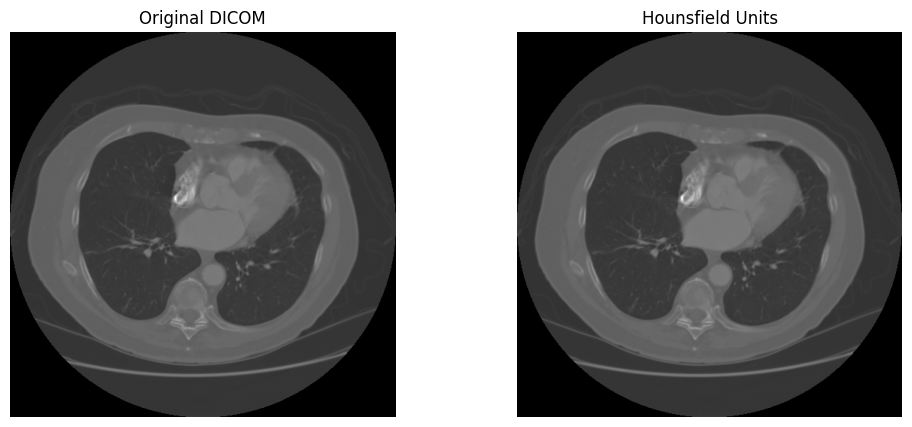

In [ ]:
import matplotlib.pyplot as plt
slice_no = len(slices) // 2

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(slices[slice_no].pixel_array, cmap="gray")
plt.title("Original DICOM")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(hu_volume[slice_no], cmap="gray")
plt.title("Hounsfield Units")
plt.axis("off")

plt.show()

##9. Verify HU Values

In [ ]:
print("HU Statistics")
print("------------------------")
print("Shape:", hu_volume.shape)
print("Minimum:", hu_volume.min())
print("Maximum:", hu_volume.max())
print("Mean:", hu_volume.mean())
print("Standard Deviation:", hu_volume.std())

HU Statistics
------------------------
Shape: (133, 512, 512)
Minimum: -2048
Maximum: 3071
Mean: -826.9439289121699
Standard Deviation: 773.4047669687984


##10. Plot HU Histogram

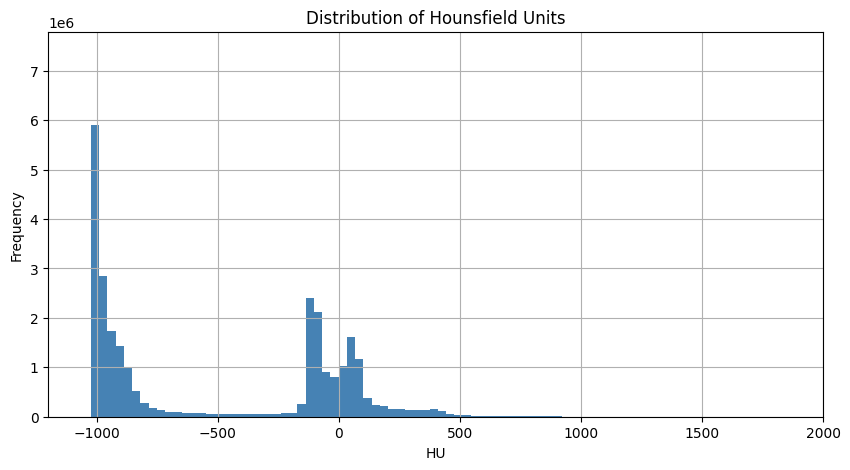

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    hu_volume.flatten(),
    bins=150,
    color="steelblue"
)

plt.title("Distribution of Hounsfield Units")
plt.xlabel("HU")
plt.ylabel("Frequency")
plt.xlim(-1200,2000)

plt.grid(True)

plt.show()

##11. Apply Lung Window

In [ ]:
def apply_lung_window(image, window_center=-600, window_width=1500):
    lower = window_center - window_width / 2
    upper = window_center + window_width / 2

    image = np.clip(image, lower, upper)
    return image

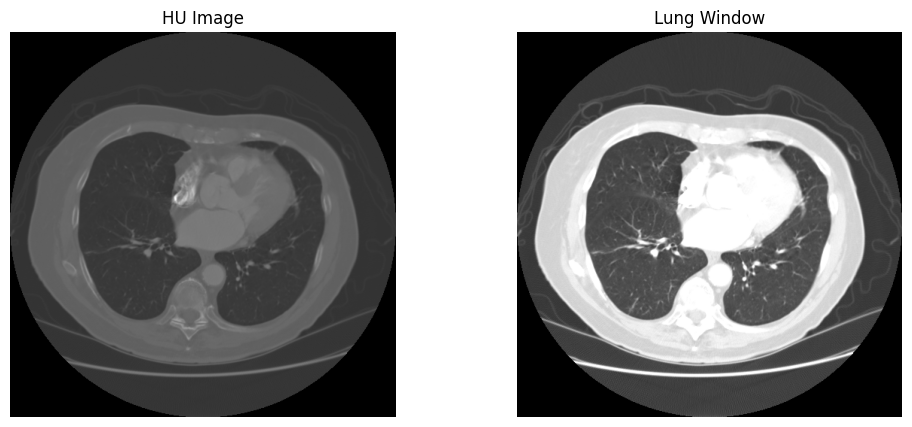

In [ ]:
lung_window = apply_lung_window(hu_volume)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(hu_volume[slice_no], cmap="gray")
plt.title("HU Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(lung_window[slice_no], cmap="gray")
plt.title("Lung Window")
plt.axis("off")

plt.show()

##12. Get Current Spacing

In [ ]:
def get_spacing(slices):
    """
    Return voxel spacing as:
    [slice_thickness, pixel_spacing_y, pixel_spacing_x]
    """

    slice_thickness = float(slices[0].SliceThickness)

    pixel_spacing = slices[0].PixelSpacing

    return np.array([
        slice_thickness,
        float(pixel_spacing[0]),
        float(pixel_spacing[1])
    ])

In [ ]:
spacing = get_spacing(slices)

print("Current voxel spacing:", spacing)

Current voxel spacing: [2.5      0.703125 0.703125]


##13. Resample Volume

In [ ]:
from scipy.ndimage import zoom

def resample(image, spacing, new_spacing=[1,1,1]):
    """
    Resample CT volume to isotropic spacing.
    """

    spacing = np.array(spacing, dtype=np.float32)
    new_spacing = np.array(new_spacing, dtype=np.float32)

    resize_factor = spacing / new_spacing

    new_shape = np.round(image.shape * resize_factor)

    real_resize = new_shape / image.shape

    new_spacing = spacing / real_resize

    image = zoom(image, real_resize, mode="nearest")

    return image, new_spacing

##14. Apply Resampling

In [ ]:
resampled_volume, new_spacing = resample(
    hu_volume,
    spacing
)

print("Original Shape :", hu_volume.shape)

print("Resampled Shape:", resampled_volume.shape)

print("New Spacing:", new_spacing)

Original Shape : (133, 512, 512)
Resampled Shape: (332, 360, 360)
New Spacing: [1.00150602 1.         1.        ]


##15. Compare Before & After

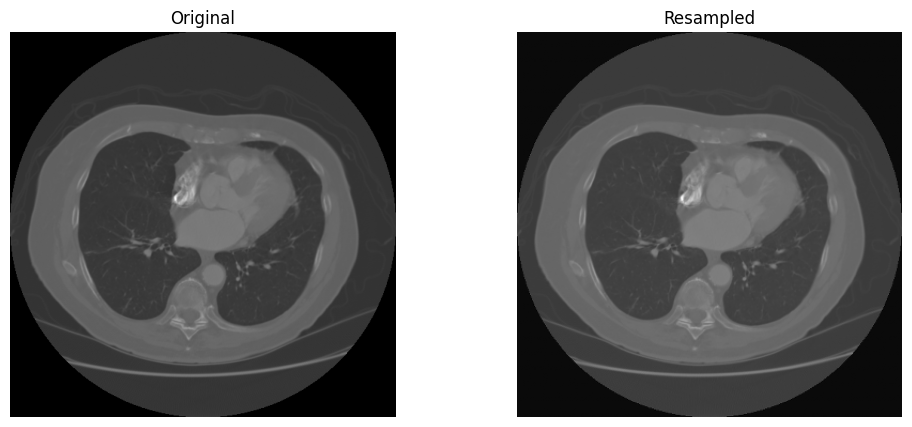

In [ ]:
slice_old = hu_volume.shape[0] // 2
slice_new = resampled_volume.shape[0] // 2

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(hu_volume[slice_old], cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(resampled_volume[slice_new], cmap="gray")
plt.title("Resampled")
plt.axis("off")

plt.show()

##16. Save the Resampled Volume

In [ ]:
import os

processed_path = "/content/drive/MyDrive/Dissertation/Dataset/Processed"

os.makedirs(processed_path, exist_ok=True)

np.save(
    os.path.join(processed_path, f"{patient.name}_HU.npy"),
    resampled_volume
)

print("Saved successfully.")

Saved successfully.


In [ ]:
from pathlib import Path

xml_files = list(annotation_xml_path.rglob("*.xml"))

print("Number of XML files:", len(xml_files))

if len(xml_files) > 0:
    print("Example XML:")
    print(xml_files[0])

Number of XML files: 1319
Example XML:
/content/drive/MyDrive/Dissertation/Dataset/ANNOTATION_STAGING/LIDC-XML-only/161-resubmitted-correction-3-9-12.xml
